In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from SamplingMethods import Sampler_class
import plotly.express as px
from ax.api.client import Client

# Model Mk4

In [2]:
client = Client()
client = client.load_from_json_file("/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/writing/papers/UoC_Paper1/Sandbox/Modelling/ModelMk4.json")
client.get_next_trials(max_trials=1)
n = 10
iCoords_arr = np.linspace(0,1,n-1)
jCoords_arr = np.linspace(0,1,n-1)
kCoords_arr = np.linspace(0,1,n-1)
ijkCoordsOld_lis = []
ijkCoords_lis = []
for i in iCoords_arr:
    for j in jCoords_arr:
        for k in kCoords_arr:
            ijkCoordsOld_lis.append([i,j,k])
            ijkCoords_lis.append({"s1":i,"s2":j,"b1":k})
y_pred = client.predict(ijkCoords_lis)
y_pred_lis = []
for i in y_pred:
    y_pred_lis.append(i["t1"][0])
ijkCoordsOld_arr = np.array(ijkCoordsOld_lis)
y_pred_arr = np.array(y_pred_lis)
df2 = pd.DataFrame({'s1': ijkCoordsOld_arr[:, 0],'s2': ijkCoordsOld_arr[:, 1],'b1': ijkCoordsOld_arr[:, 2], 'y_pred': y_pred_arr})

fig = px.scatter_3d(df2, x='s1', y='s2', z='b1', color='y_pred')
fig.show()

/Users/thomasdodd/miniconda3/envs/Ax1_env/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(


In [3]:
pseudorandom_100_dodd_27 = pd.read_pickle(filepath_or_buffer="/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/writing/papers/UoC_Paper1/Sandbox/SequentialTestswGPModel/DataGenerated/set_random_27.pkl")[0].tolist()
quasirandom_100_dodd_27 = pd.read_pickle(filepath_or_buffer="/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/writing/papers/UoC_Paper1/Sandbox/SequentialTestswGPModel/DataGenerated/set_sobol_27.pkl")[0].tolist()
Bayes_100_PI_9_27_1 = pd.read_pickle(filepath_or_buffer="/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/writing/papers/UoC_Paper1/Sandbox/SequentialTestswGPModel/DataGenerated/set_PI_9_27_1.pkl")[0].tolist()
Bayes_100_EI_9_27_1 = pd.read_pickle(filepath_or_buffer="/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/writing/papers/UoC_Paper1/Sandbox/SequentialTestswGPModel/DataGenerated/set_EI_9_27_1.pkl")[0].tolist()
Bayes_100_EI_9_27_2 = pd.read_pickle(filepath_or_buffer="/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/writing/papers/UoC_Paper1/Sandbox/SequentialTestswGPModel/DataGenerated/set_EI_9_27_2.pkl")[0].tolist()
Bayes_100_EI_9_27_3 = pd.read_pickle(filepath_or_buffer="/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/writing/papers/UoC_Paper1/Sandbox/SequentialTestswGPModel/DataGenerated/set_EI_9_27_3.pkl")[0].tolist()

Simulations = [pseudorandom_100_dodd_27,quasirandom_100_dodd_27,Bayes_100_PI_9_27_1,Bayes_100_EI_9_27_1,Bayes_100_EI_9_27_2,Bayes_100_EI_9_27_3]

all = pseudorandom_100_dodd_27+quasirandom_100_dodd_27+Bayes_100_PI_9_27_1+Bayes_100_EI_9_27_1+Bayes_100_EI_9_27_2+Bayes_100_EI_9_27_3

print(len(pseudorandom_100_dodd_27))
print(len(quasirandom_100_dodd_27))
print(len(Bayes_100_PI_9_27_1))
print(len(Bayes_100_EI_9_27_1))
print(len(Bayes_100_EI_9_27_2))
print(len(Bayes_100_EI_9_27_3))

1000
1000
1000
1000
1000
1000


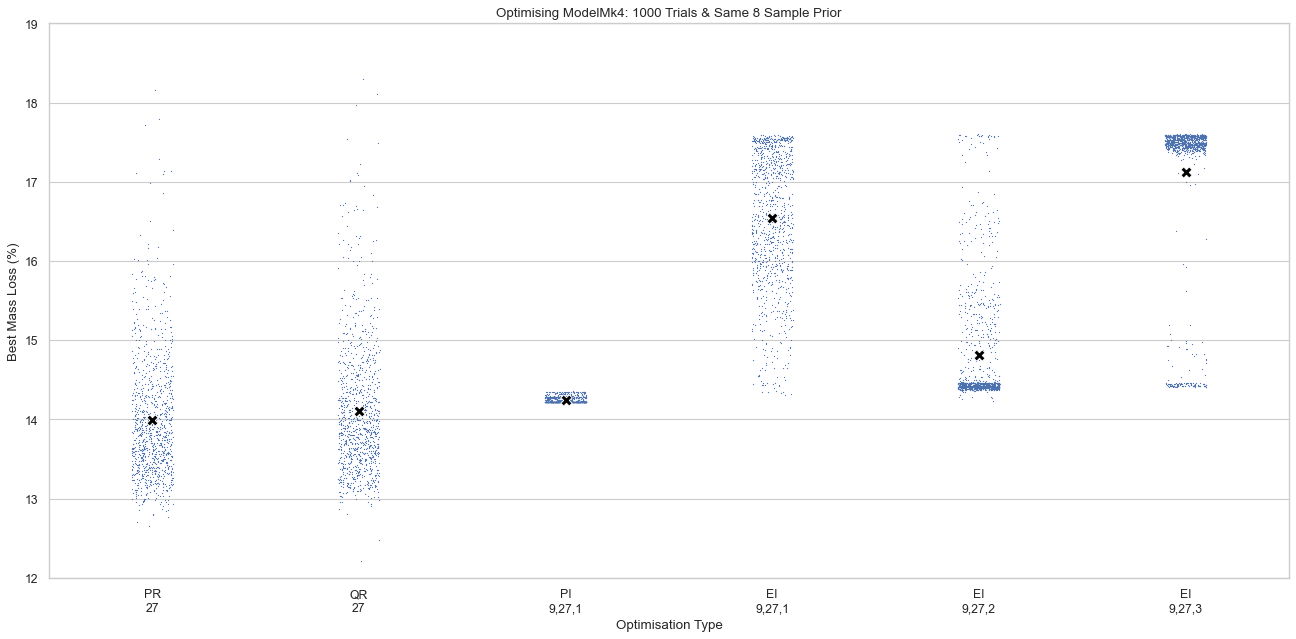

In [10]:
pseudorandom_100_dodd_27_name = []
quasirandom_100_dodd_27_name = []
Bayes_100_PI_9_27_1_name = []
Bayes_100_EI_9_27_1_name = []
Bayes_100_EI_9_27_2_name = []
Bayes_100_EI_9_27_3_name = []
for i in range(len(pseudorandom_100_dodd_27)):
    pseudorandom_100_dodd_27_name.append("PR\n27")
    quasirandom_100_dodd_27_name.append("QR\n27")
    Bayes_100_PI_9_27_1_name.append("PI\n9,27,1")
    Bayes_100_EI_9_27_1_name.append("EI\n9,27,1")
    Bayes_100_EI_9_27_2_name.append("EI\n9,27,2")
    Bayes_100_EI_9_27_3_name.append("EI\n9,27,3")

all_names = pseudorandom_100_dodd_27_name+quasirandom_100_dodd_27_name+Bayes_100_PI_9_27_1_name+Bayes_100_EI_9_27_1_name+Bayes_100_EI_9_27_2_name+Bayes_100_EI_9_27_3_name

ndf = pd.DataFrame({"y":all,"type":all_names})
ndf

sns.set_theme(style="whitegrid")
from matplotlib.pyplot import figure
figure(figsize=(20, 9), dpi=80)
ax = sns.stripplot(x="type", y="y", data=ndf, size=1.1)
# ax = sns.swarmplot(x="type", y="y", data=ndf, size=0.3)
df_means = ndf.groupby("type")["y"].agg("mean").reset_index()
xlim = ax.get_xlim()
ylim = ax.get_ylim()
sns.scatterplot(x="type", y="y", marker='X', color='black', s=100, zorder=3, ax=ax, legend=False, data=df_means)
ax.set_xlim(xlim)
ax.set_ylim(ylim)
plt.title(f"Optimising ModelMk4: {len(pseudorandom_100_dodd_27)} Trials & Same 8 Sample Prior")
plt.xlabel("Optimisation Type")
plt.ylabel("Best Mass Loss (%)")
plt.ylim(bottom=12,top=19)
plt.show()

In [5]:
# Global Maximum
# 18.766577458826873
# [np.float64(0.3469387755102041), np.float64(0.6530612244897959), np.float64(0.7653061224489796)]

In [6]:
Threshold = 18.5
SimulationNumberOfPointsExceedingThreshold = []
PercentageOfPointsExceedingThreshold = []
for simulation in Simulations:
    counter = 0
    for i in simulation:
        if i > Threshold:
            counter+=1
    SimulationNumberOfPointsExceedingThreshold.append(counter)
    PercentageOfPointsExceedingThreshold.append(round((counter/len(simulation))*100,2))
print(SimulationNumberOfPointsExceedingThreshold)

print(PercentageOfPointsExceedingThreshold)

[0, 0, 0, 0, 0, 0]
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
